What's New and Changed in version 2.10.210918
---------------------------------------------------------------------

New functions:

    - Added dtw() for generic dynamic time warping with predefined and custom defined step pattern.
    - Added wavedec() for multi-level discrete wavelet transformation, and waverec() for the corresponding inverse transformation.
    - Added wpdec() and wprec() for multi-level (discrete) wavelet packet transformation and inverse.
    - Added OnlineMultiLogisticRegression() which is the online version of Multi-Class Logistic Regression.
    - Added spectral clustering.
    - Added LSTM with attention.
    - Added OneHotEncoding.
    - Added unified preprocessor.
    - Added Pipeline plot.

Enhancement:

    - Enhanced the model storage support for OnlineLinearRegression().
    - Enhanced multi-threading in tm functions.
    - Enhanced HDL container option.
    - Enhanced timestamp support for ARIMA(), AutoARIMA(), VectorARIMA(), OnlineARIMA(),
      SingleExponentialSmoothing(), DoubleExponentialSmoothing(), TripleExponentialSmoothing(),
      AutoExponentialSmoothing(), BrownExponentialSmoothing(), Croston(), LR_seasonal_adjust().
    - Enhanced new distributions for MCMC sampling.
    - Support mutilple accuracy_measure methods in Single/Double/Triple ExponentialSmoothing, BrownExponentialSmoothing, Croston and LR_seasonal_adjust.
    - Added plotly support.

API change:

    - Added `categorical_variable` in the fit() function of AdditiveModelForecast().
    - Added `prediction_confidence_1` and `prediction_confidence_2` in BrownExponentialSmoothing().


## Connect to your SAP HANA (Cloud | Platfrom) instance

The latest Python ML client for SAP HANA package update is ready for installation and can be found at: https://pypi.org/project/hana-ml/

In [1]:
## Review the python env and version used by the kernel
import sys
print(sys.base_prefix)
print(sys.prefix)
import logging
logging.basicConfig(level=logging.WARNING)

## Loading the Python Machine Learning client library for SAP HANA and get the version
import hana_ml
print(hana_ml.__version__)

C:\Users\D059078\AppData\Local\Programs\Python\Python312
C:\Users\D059078\AppData\Local\Programs\Python\envs\hanaml_env
2.30.26091504


Create the SAP HANA connection by specifying connection credentials

In [2]:
# Create the SAP HANA CLoud connection
import hana_ml.dataframe as dataframe
#cc = dataframe.ConnectionContext( address="<hana-cloud-hostname>", port=443,  user="<HANA-user>", sslValidateCertificate=False)
#cc = dataframe.ConnectionContext( userkey=<your-key-name>, sslValidateCertificate=False)

# Utilize connection credentials from external file
from hana_ml.dataframe import ConnectionContext
from hana_ml.algorithms.pal.utility import Settings, DataSets
url, port, user, pwd = Settings.load_config("../../config/e2edata.ini", "hana")
connection_context = ConnectionContext(url, port, user, pwd, sslValidateCertificate=False)


# Control connection
print(connection_context.connection.isconnected())
print('Connected -- HANA version:', connection_context.hana_version())
print("Current schema:", connection_context.get_current_schema())

True
Connected -- HANA version: 4.00.000.00.1786441019 (fa/CE2026.28)
Current schema: HANAML_TEST


Alternatively, connect using the secure user connection store (hdbuserstore) and a connection key, see  [documentation](https://help.sap.com/docs/SAP_HANA_CLIENT/f1b440ded6144a54ada97ff95dac7adf/708e5fe0e44a4764a1b6b5ea549b88f4.html).  

## Plotly support

In [3]:
from hana_ml.algorithms.pal.utility import DataSets
full_set, training_set, validation_set, test_set = DataSets.load_titanic_data(connection_context, force=False, chunk_size=50000)
data = full_set
data.head(5).collect()

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.61it/s]


,PASSENGER_ID,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,CABIN,EMBARKED,SURVIVED
0,892,3,"Kelly\, Mr. James",male,34.5,0,0,330911,7.8292,None,Q,0
1,893,3,"Wilkes\, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,None,S,0
2,894,2,"Myles\, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,None,Q,0
3,895,3,"Wirz\, Mr. Albert",male,27.0,0,0,315154,8.6625,None,S,0
4,896,3,"Hirvonen\, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,None,S,0


In [4]:
from hana_ml import dataframe
from hana_ml.algorithms.pal import trees
from hana_ml.visualizers.eda import EDAVisualizer as eda
import pandas as pd
import matplotlib.pyplot as plt
from hana_ml.visualizers.eda import EDAVisualizer, hist, kdeplot

### Distribution plot

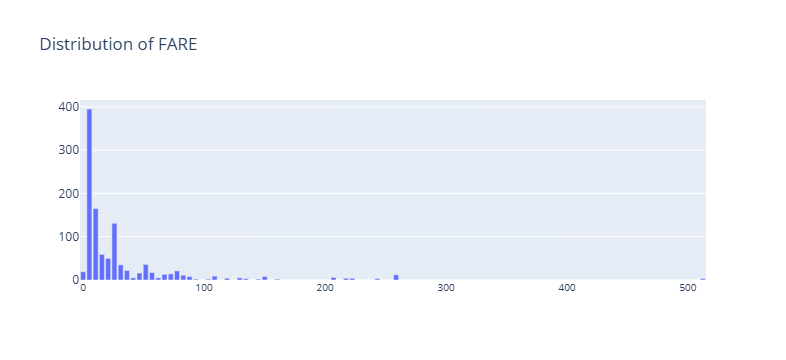

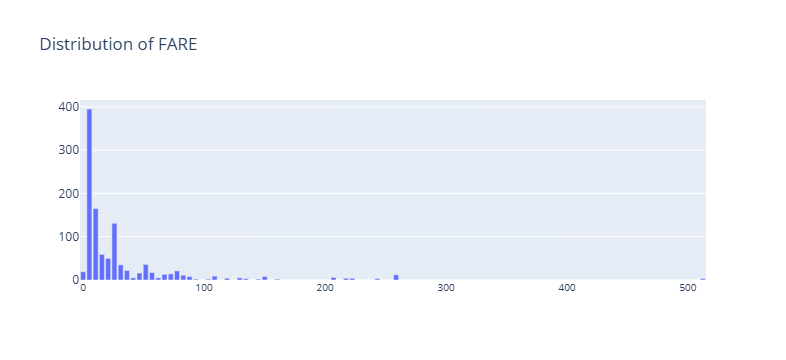

In [5]:
eda = EDAVisualizer(enable_plotly=True)
fig, trace, dist_data = eda.distribution_plot(data=data, column="FARE", bins=100, title="Distribution of FARE")
fig.show()

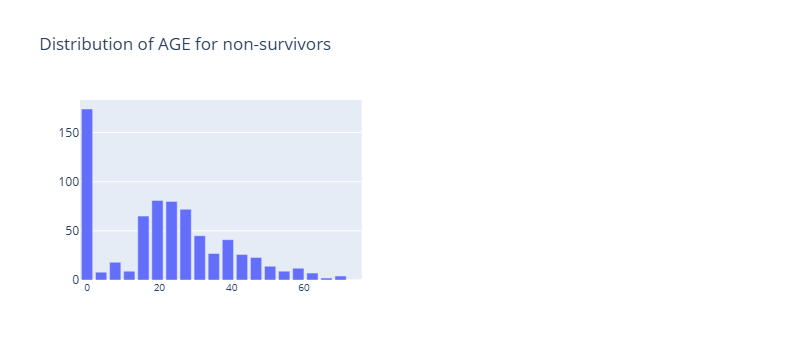

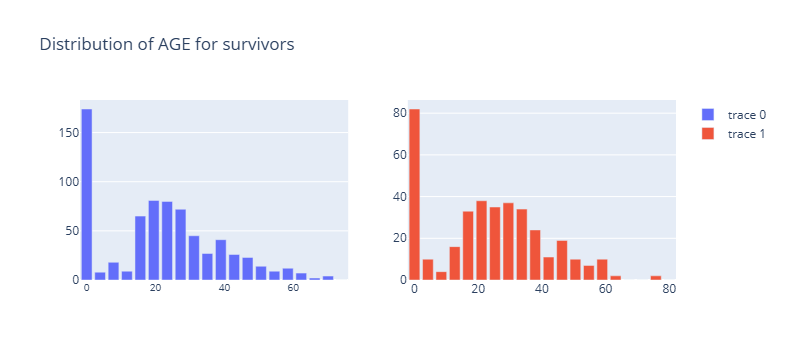

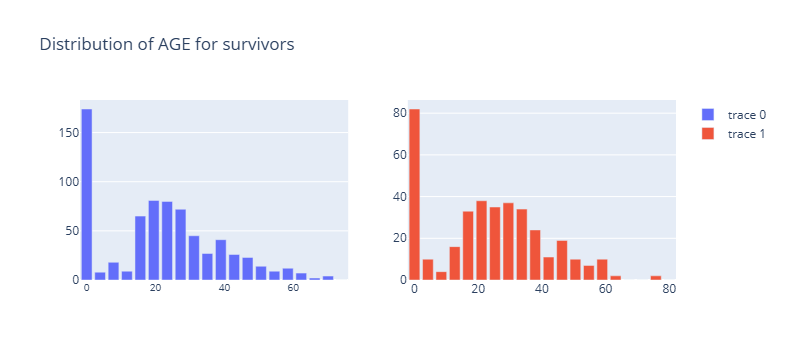

In [6]:
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=2)
eda = EDAVisualizer(enable_plotly=True, fig=fig)
eda.distribution_plot(data=data.filter("SURVIVED = 0"), column="AGE", bins=20, title="Distribution of AGE for non-survivors", subplot_pos=(1, 1))
fig, _, _ = eda.distribution_plot(data=data.filter("SURVIVED = 1"), column="AGE", bins=20, title="Distribution of AGE for survivors", subplot_pos=(1, 2))
fig.show()

### kde plot

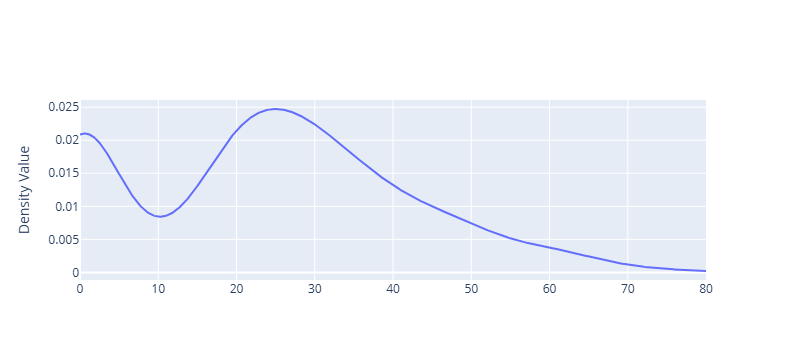

In [7]:
fig = kdeplot(data, key="PASSENGER_ID", features=["AGE"], enable_plotly=True)
fig.show()

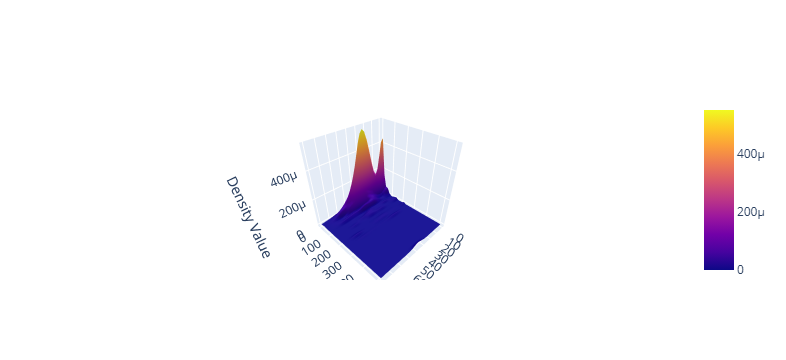

In [8]:
fig = kdeplot(data, key="PASSENGER_ID", features=["AGE", "FARE"], enable_plotly=True)

fig.show()

### Pie plot

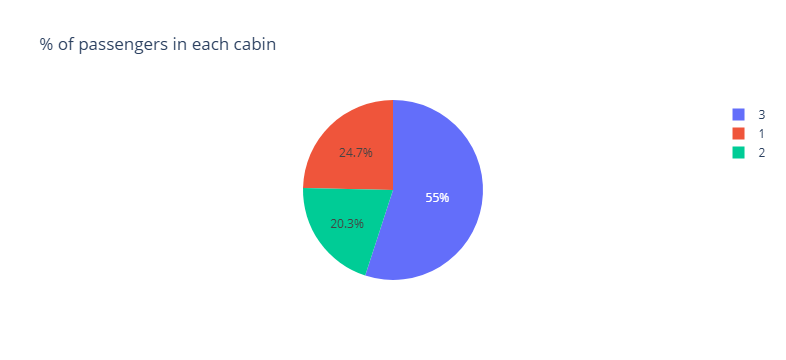

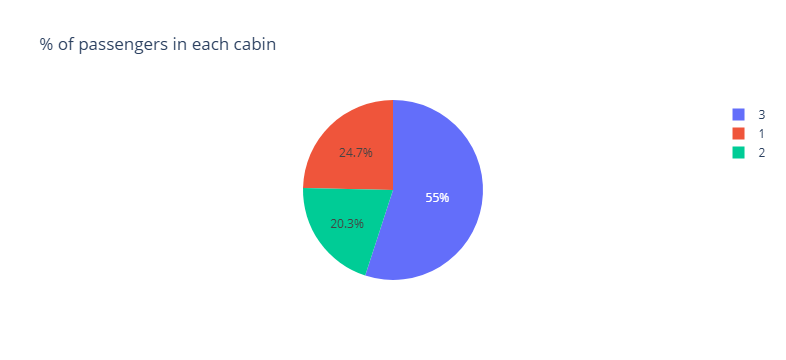

In [9]:
eda = EDAVisualizer(enable_plotly=True)
fig, pie_data = eda.pie_plot(data, column="PCLASS", title="% of passengers in each cabin")

fig.show()

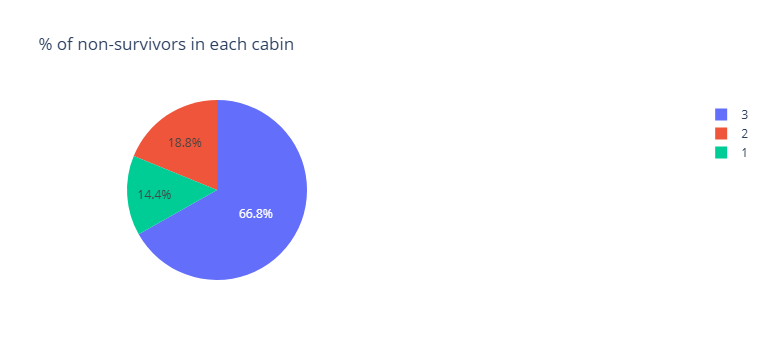

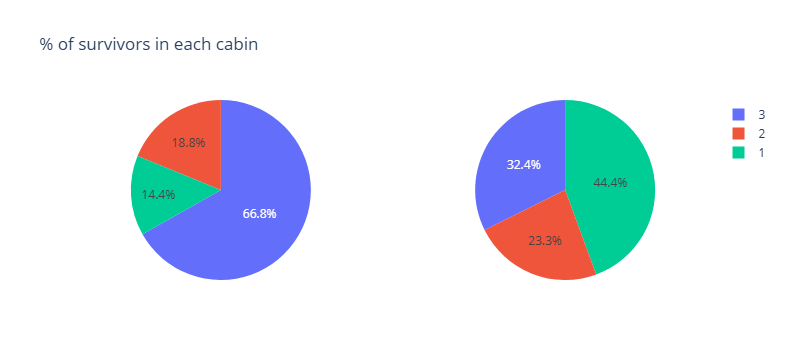

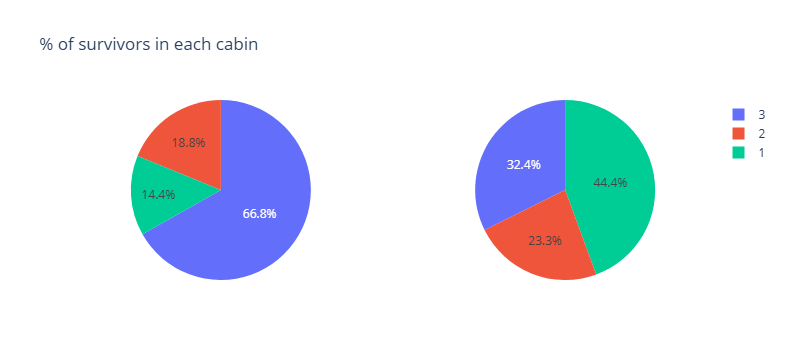

In [19]:
fig = make_subplots(rows=1, cols=2, specs=[[{"type": "pie"}, {"type": "pie"}]])
eda = EDAVisualizer(enable_plotly=True, fig=fig)
eda.pie_plot(data=data.filter("SURVIVED = 0"), column="PCLASS", title="% of non-survivors in each cabin", subplot_pos=(1, 1))
fig, pie_data = eda.pie_plot(data=data.filter("SURVIVED = 1"), column="PCLASS", title="% of survivors in each cabin", subplot_pos=(1, 2))
fig.show()

### Correlation plot

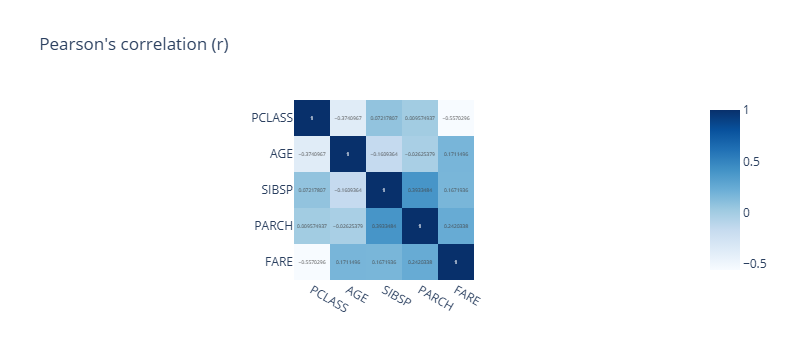

In [11]:
fig, corr = eda.correlation_plot(data=data, corr_cols=['PCLASS', 'AGE', 'SIBSP', 'PARCH', 'FARE'], cmap="Blues")

fig.show()

### Histogram

In [28]:
from hana_ml.visualizers.eda import hist
hist(data=data, columns=['PCLASS', 'AGE', 'SIBSP', 'PARCH', 'FARE'], default_bins=20, bins={"AGE": 10}, enable_plotly=True)

### Scatter plot

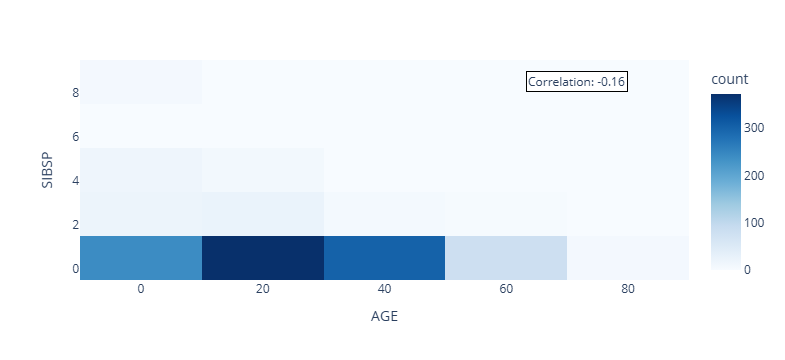

In [23]:
fig = eda.scatter_plot(data=data, x="AGE", y="SIBSP", x_bins=5, y_bins=5)
fig.show()

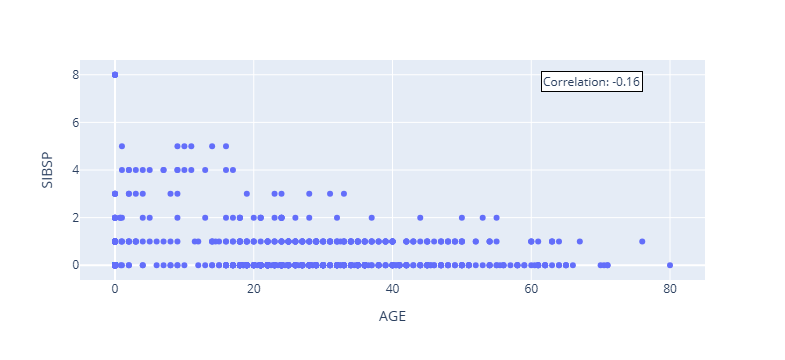

In [24]:
fig = eda.scatter_plot(data=data, x="AGE", y="SIBSP", sample_frac=0.8)
fig.show()

### Box plot

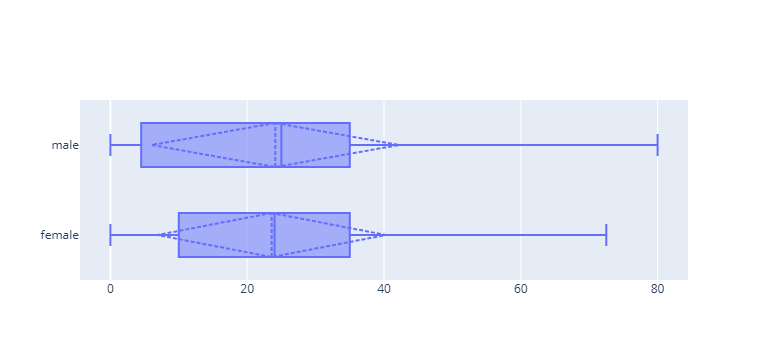

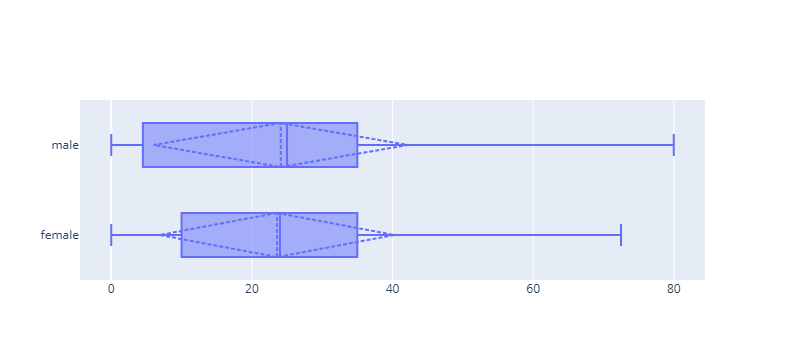

In [26]:
eda = EDAVisualizer(enable_plotly=True)
fig, corr = eda.box_plot(data=data, column="AGE", groupby="SEX")
fig.show()

### Confusion matrix

In [48]:
# Load the diabetes datasets
diabetes_full, diabetes_train, diabetes_test, _ = DataSets.load_diabetes_data(connection_context)


Table PIMA_INDIANS_DIABETES_TBL exists.


In [34]:
from hana_ml.algorithms.pal import metricsfrom hana_ml.algorithms.pal.unified_classification import UnifiedClassification


rdt_params = dict(random_state=2,
                  split_threshold=1e-7,
                  min_samples_leaf=1,
                  n_estimators=10,
                  max_depth=55)
uc_rdt = UnifiedClassification(func = 'RandomForest', **rdt_params)

uc_rdt.fit(data=diabetes_train,
           key= 'ID', 
           label='CLASS',
           partition_method='stratified',
           stratified_column='CLASS', 
           partition_random_state=2,
           training_percent=0.7, ntiles=2)

features = diabetes_train.columns
features.remove('CLASS')
features.remove('ID')
pred_res = uc_rdt.predict(diabetes_test, key='ID', features=features)
ts = diabetes_test.rename_columns({'ID': 'TID'}) .cast('CLASS', 'NVARCHAR(256)')
jsql = '{}."{}"={}."{}"'.format(pred_res.quoted_name, 'ID', ts.quoted_name, 'TID')
results_df = pred_res.join(ts, jsql, how='inner')
cm_df, classification_report_df = metrics.confusion_matrix(results_df, key='ID', label_true='CLASS', label_pred='SCORE') 

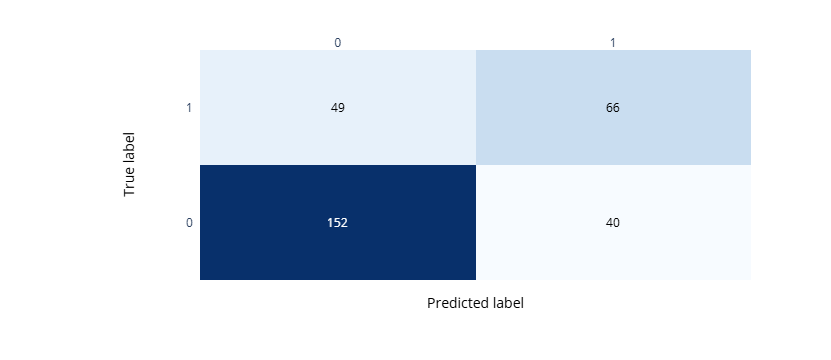

In [35]:
from hana_ml.visualizers.metrics import MetricsVisualizer
mv1 = MetricsVisualizer(enable_plotly=True)
fig = mv1.plot_confusion_matrix(cm_df, normalize=False)
fig.show()

## Time Series Forecast Plot

In [36]:
import numpy as np
import pandas as pd
from hana_ml.dataframe import create_dataframe_from_pandas
def geometric_brownian_motion(T = 1, N = 2, mu = -0.01, sigma = 0.001, S0 = 2):        
    dt = float(T)/N
    t = np.linspace(0, T, N)
    W = np.random.standard_normal(size = N) 
    W = np.cumsum(W)*np.sqrt(dt) ### standard brownian motion ###
    X = (mu-0.5*sigma**2)*t + sigma*W 
    S = S0*np.exp(X) ### geometric brownian motion ###
    return S

dates = pd.date_range('2018-03-01', '2018-03-10',freq='H')
T = (dates.max()-dates.min()).days / 365
N = dates.size
start_price = 1000
y = pd.DataFrame()
y['INDEX'] = dates
y['Y'] = geometric_brownian_motion(T, N, sigma=0.1, S0=start_price)
df = dataframe.create_dataframe_from_pandas(connection_context, y, '#AMF_TEST', force=True).sort("INDEX")
tsfp_train = df.filter("DAYS_BETWEEN(INDEX, '2018-03-06') > 0")
tsfp_test = df.filter("DAYS_BETWEEN(INDEX, '2018-03-06') <= 0")

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 24.00it/s]


In [38]:
from hana_ml.algorithms.pal.tsa.additive_model_forecast import AdditiveModelForecast

amf = AdditiveModelForecast(growth='linear')
amf.fit(data=tsfp_train)
pred_data = amf.predict(data=tsfp_test)

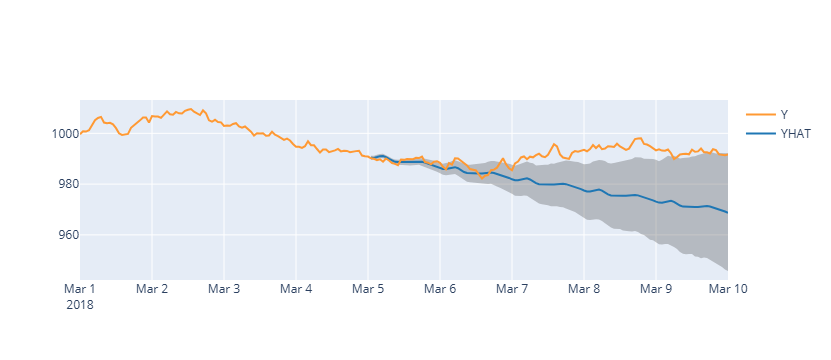

In [39]:
from hana_ml.visualizers.visualizer_base import forecast_line_plot

forecast_line_plot(pred_data=pred_data.set_index("INDEX"),
                   actual_data=df.set_index("INDEX"),
                   confidence=("YHAT_LOWER", "YHAT_UPPER"),
                   max_xticklabels=10,
                   enable_plotly=True)


## Time Series Candlestick Plot

In [41]:
data = dataframe.create_dataframe_from_pandas(connection_context=connection_context,
                                              pandas_df=pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/finance-charts-apple.csv'),
                                              table_name="#candlestick",
                                              force=True)

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 21.77it/s]


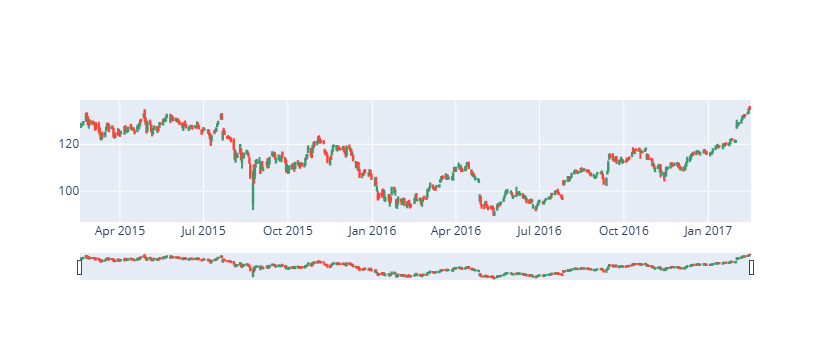

In [42]:
from hana_ml.visualizers.eda_plotly import candlestick_plot

fig = candlestick_plot(data=data.set_index("Date"), open="AAPL.Open", high="AAPL.High", low="AAPL.Low", close="AAPL.Close")
fig.show()

## Timestamp support for ARIMA, etc.

In [44]:

# y_arimax
dates = pd.date_range('2018-03-01', '2018-03-10', freq='H')
T = (dates.max()-dates.min()).days / 365
N = dates.size
start_price = 1000
y_arimax = pd.DataFrame()
y_arimax['INDEX'] = dates
y_arimax['Y'] = geometric_brownian_motion(T, N, sigma=0.1, S0=start_price)
y_arimax['EX'] = geometric_brownian_motion(T, N, sigma=0.1, S0=start_price)
df_arimax = create_dataframe_from_pandas(connection_context, y_arimax, '#ARIMAX_TIMESTAMP', force=True).sort("INDEX")
print(df_arimax.collect())

# y_ariamx predict
dates = pd.date_range('2018-03-10', '2018-03-11', freq='H')
T = (dates.max()-dates.min()).days / 365
N = dates.size
start_price = 1000
predict_arimax = pd.DataFrame()
predict_arimax['INDEX'] = dates
predict_arimax['EX'] = geometric_brownian_motion(T, N, sigma=0.1, S0=start_price)
predict_arimax_df = create_dataframe_from_pandas(connection_context, predict_arimax, '#ARIMAX_PREDICT_TIMESTAMP', force=True).sort("INDEX")
print(predict_arimax_df.collect())

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 23.30it/s]


                  INDEX            Y           EX
0   2018-03-01 00:00:00   999.717130  1001.282981
1   2018-03-01 01:00:00  1000.062971  1000.408389
2   2018-03-01 02:00:00   999.583485  1001.328850
3   2018-03-01 03:00:00   998.351050  1001.340177
4   2018-03-01 04:00:00   996.811880  1001.573279
..                  ...          ...          ...
212 2018-03-09 20:00:00   973.612258  1015.650114
213 2018-03-09 21:00:00   974.105527  1014.680548
214 2018-03-09 22:00:00   973.267074  1015.190237
215 2018-03-09 23:00:00   971.862827  1014.790181
216 2018-03-10 00:00:00   972.451050  1013.918253

[217 rows x 3 columns]


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 20.09it/s]

                 INDEX           EX
0  2018-03-10 00:00:00   999.565253
1  2018-03-10 01:00:00  1000.710594
2  2018-03-10 02:00:00  1000.962479
3  2018-03-10 03:00:00  1002.573630
4  2018-03-10 04:00:00  1002.445433
5  2018-03-10 05:00:00  1002.982093
6  2018-03-10 06:00:00  1001.645393
7  2018-03-10 07:00:00  1002.961201
8  2018-03-10 08:00:00  1002.450984
9  2018-03-10 09:00:00  1000.880234
10 2018-03-10 10:00:00  1000.553935
11 2018-03-10 11:00:00  1000.490602
12 2018-03-10 12:00:00  1000.050099
13 2018-03-10 13:00:00  1000.101164
14 2018-03-10 14:00:00   999.448675
15 2018-03-10 15:00:00  1001.468989
16 2018-03-10 16:00:00  1001.871229
17 2018-03-10 17:00:00  1000.253317
18 2018-03-10 18:00:00   999.954787
19 2018-03-10 19:00:00  1000.352630
20 2018-03-10 20:00:00   999.854726
21 2018-03-10 21:00:00  1001.307453
22 2018-03-10 22:00:00  1000.046746
23 2018-03-10 23:00:00   998.813471
24 2018-03-11 00:00:00   999.191177


## AutoML Unified Preprocessing

In [45]:
from hana_ml.algorithms.pal.auto_ml import Preprocessing

In [49]:
result = Preprocessing(name="FeatureNormalizer").fit_transform(data=diabetes_full, key="ID", features=["BMI"])
result.collect()

,ID,BMI
0,0,0.234415
1,1,0.116567
2,2,0.253629
3,3,0.038002
4,4,0.943638
...,...,...
763,763,0.039710
764,764,0.111870
765,765,0.071307
766,766,0.115713


In [51]:
result = Preprocessing(name="OneHotEncoder").fit_transform(data=diabetes_full, key="ID", features=["CLASS"])
result.collect()

,ID,INSULIN,PREGNANCIES,GLUCOSE,AGE,BMI,SKINTHICKNESS,1_CLASS_OneHot,0_CLASS_OneHot
0,0,33.6,72,35,50,0.627,0,1,0
1,1,26.6,66,29,31,0.351,0,0,1
2,2,23.3,64,0,32,0.672,0,1,0
3,3,28.1,66,23,21,0.167,94,0,1
4,4,43.1,40,35,33,2.288,168,1,0
...,...,...,...,...,...,...,...,...,...
763,763,32.9,76,48,63,0.171,180,0,1
764,764,36.8,70,27,27,0.340,0,0,1
765,765,26.2,72,23,30,0.245,112,0,1
766,766,30.1,60,0,47,0.349,0,1,0


## Pipeline Plot

In [72]:
display(diabetes_train.describe().collect())
display(diabetes_train.dtypes())

,column,count,unique,nulls,mean,std,min,max,min_value,max_value,median,25_percent_cont,25_percent_disc,50_percent_cont,50_percent_disc,75_percent_cont,75_percent_disc
0,ID,384,384,0,376.973958,220.456455,1.000,765.00,1,765,374.0000,185.750,185.000,373.5000,373.000,570.25000,570.000
1,PREGNANCIES,384,41,0,70.171875,18.761291,0.000,110.00,0,110,72.0000,64.000,64.000,72.0000,72.000,80.00000,80.000
2,GLUCOSE,384,49,0,20.200521,16.293614,0.000,99.00,0,99,22.0000,0.000,0.000,22.0000,22.000,33.00000,33.000
3,SKINTHICKNESS,384,129,0,79.802083,115.684284,0.000,744.00,0,744,21.0000,0.000,0.000,20.5000,18.000,128.50000,128.000
4,INSULIN,384,185,0,31.643750,8.193018,0.000,59.40,0,59.4,31.6000,27.000,27.000,31.6000,31.600,36.40000,36.400
5,BMI,384,307,0,0.467180,0.340626,0.078,2.42,0.078,2.42,0.3615,0.238,0.238,0.3615,0.361,0.62675,0.626
6,AGE,384,47,0,33.776042,12.261376,21.000,81.00,21,81,30.0000,24.000,24.000,30.0000,30.000,41.00000,41.000
7,CLASS,384,2,0,0.359375,0.480443,0.000,1.00,0,1,0.0000,0.000,0.000,0.0000,0.000,1.00000,1.000


[('ID', 'INT', 10, 10, 10, 0),
 ('PREGNANCIES', 'INT', 10, 10, 10, 0),
 ('GLUCOSE', 'INT', 10, 10, 10, 0),
 ('SKINTHICKNESS', 'INT', 10, 10, 10, 0),
 ('INSULIN', 'DOUBLE', 15, 15, 15, 0),
 ('BMI', 'DOUBLE', 15, 15, 15, 0),
 ('AGE', 'INT', 10, 10, 10, 0),
 ('CLASS', 'INT', 10, 10, 10, 0)]

In [81]:
from hana_ml.algorithms.pal.pipeline import Pipeline
from hana_ml.algorithms.pal.preprocessing import Imputer
from hana_ml.algorithms.pal.decomposition import PCA
from hana_ml.algorithms.pal.trees import HybridGradientBoostingClassifier


pipe = Pipeline([
                ('pca', PCA(scaling=True, scores=True, n_components=5)),
                ('imputer', Imputer(strategy='mean'))
                ])

param = {'pca__key': 'ID', 'pca__label': 'CLASS'}
data = pipe.fit_transform(diabetes_train, fit_params=param)
data.head(3).collect()

,ID,COMPONENT_1,COMPONENT_2,COMPONENT_3,COMPONENT_4,COMPONENT_5,COMPONENT_6,CLASS
0,1,-0.522299,-0.251096,-0.346352,-0.093120,0.310510,0.895908,0
1,3,-0.450682,-0.761419,-1.031394,-0.411257,0.348643,-0.078162,0
2,4,2.565374,-2.434882,3.747779,2.568389,-1.132789,0.301340,1


In [82]:
pipe = Pipeline([('pca', PCA(scaling=True, scores=True, n_components=5)),
                 ('hgbt', HybridGradientBoostingClassifier( n_estimators=4, split_threshold=0 ,
                                                          learning_rate=0.5, fold_num=5 ,max_depth=6))
                ])

param = {'pca__key': 'ID', 'pca__label': 'CLASS', 'hgbt__key': 'ID', 'hgbt__label': 'CLASS'}
pipe.fit(diabetes_train, fit_params=param)

In [83]:
pipe.plot()

## Spectral Clustering

Note, this dataset is provided in the folder [hana-ml-samples/Python-API-pal/datasets](https://github.com/SAP-samples/hana-ml-samples/tree/main/Python-API/pal/datasets).

In [85]:
import pandas as pd
from hana_ml.dataframe import create_dataframe_from_pandas
mocking_data = pd.read_csv('../datasets/mocking_data_spc.csv')
cluster_df = create_dataframe_from_pandas(connection_context, mocking_data, 'CLUSTERING_TEST_DATA_1', force=True)

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 11.66it/s]


In [86]:
from hana_ml.algorithms.pal.clustering import SpectralClustering
res = SpectralClustering(n_clusters=2, affinity='knn', n_neighbors=5).fit_predict(cluster_df, key='ID')
cluster0 = cluster_df.filter('ID IN (SELECT ID FROM ({}) WHERE CLUSTER_ID = 0)'.format(res.select_statement))
cluster1 = cluster_df.filter('ID IN (SELECT ID FROM ({}) WHERE CLUSTER_ID = 1)'.format(res.select_statement))
cluster0_data = cluster0.collect()
cluster1_data = cluster1.collect()

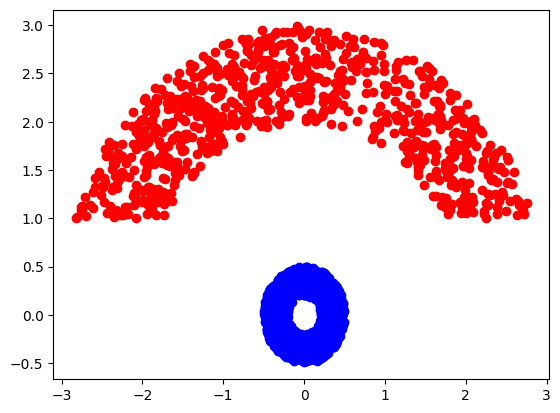

In [87]:
import matplotlib.pyplot as plt
plt.scatter(cluster0_data['X'], cluster0_data['Y'], color='blue')
plt.scatter(cluster1_data['X'], cluster1_data['Y'], color='red')
plt.show()

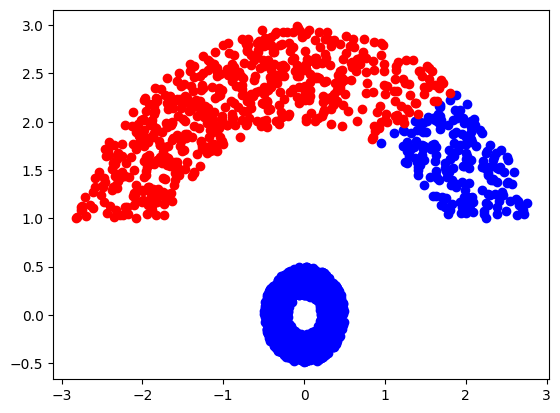

In [88]:
from hana_ml.algorithms.pal.clustering import KMeans
kmres = KMeans(n_clusters=2).fit_predict(cluster_df, key='ID')
kclust0 = cluster_df.filter('ID IN (SELECT ID FROM ({}) WHERE CLUSTER_ID = 0)'.format(kmres.select_statement))
kclust0_data = kclust0.collect()
kclust1 = cluster_df.filter('ID IN (SELECT ID FROM ({}) WHERE CLUSTER_ID = 1)'.format(kmres.select_statement))
kclust1_data = kclust1.collect()
plt.scatter(kclust0_data['X'], kclust0_data['Y'], color='blue')
plt.scatter(kclust1_data['X'], kclust1_data['Y'], color='red')
plt.show()